# Предсказание знака изменения свободной энергии связывания (ddG) на основе SKEMPI 2.0

В этом ноутбуке реализована базовая модель машинного обучения для предсказания **знака изменения свободной энергии связывания** (`ddG_sign`) при мутациях в белковых комплексах. В качестве исходных данных используется база **SKEMPI 2.0**, содержащая экспериментальные значения изменения свободной энергии связывания (`ΔΔG`) и структурную информацию о белках.

**Цель**: продемонстрировать обучаемость простой классификационной модели

**Контекст задачи**: - Признак `ddG_sign` (положительный или отрицательный ΔΔG) отражает **стабилизирующий или дестабилизирующий эффект мутации**.

## Что сделано

- Обоснован выбор признаков на основе:
  - физико-химических свойств аминокислот
  - позиции мутации
  - структурного контекста (в меньшей степени, нет подгрузки из pdb.dssp и получения информации о температурном факторе или типе вторичной структуры)

- Проведена предобработка данных:
  - нормализация числовых признаков
  - one-hot кодирование категориальных

- Обучены три модели:
  - **Логистическая регрессия**
  - **K-ближайших соседей (KNN)**
  - **CatBoostClassifier**

- Проведена кросс-валидация (**Stratified K-Fold**), рассчитаны метрики:
  - Balanced Accuracy  
  - F1-score  
  - MCC  
  - ROC AUC

- Выделены **важные признаки** для итоговой модели.

In [ ]:
!pip install biopython catboost blosum

# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from Bio import PDB
import os

import blosum as bl
from sklearn.model_selection import cross_validate,StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, f1_score, roc_auc_score, make_scorer
from catboost import CatBoostClassifier, Pool
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = Path('/kaggle/input/data-test/skempi_v2.csv')

## Обоснование признаков для предсказания ΔΔG (знака изменения энергии связывания)

Чтобы понять, как аминокислотная мутация влияет на энергию связывания белкового комплекса, нужно учитывать не только саму замену, но и **контекст**: где эта замена произошла, какова химия заменяемых остатков, и в каких структурных условиях. 

### 1. Физико-химические свойства аминокислот

**Зачем нужны:**
- Отражают, как мутация может повлиять на структуру и стабильность комплекса: нарушить контакты, влезть не по размеру или изменить заряд в критичном месте.

**Что используем:**
- `Δгидрофобность`, `Δобъем`, `Δзаряд` — как изменились свойства радикала.
- `Δмасса` — прокси на размер боковой цепи.
- `same_group` — осталась ли замена в пределах одного химического класса.
- `blosum62` — насколько "естественна" замена по частоте эволюции (низкое значение → редкая, вероятно, вредная замена).

### 2. Позиция и контекст мутации

**Зачем нужны:**
- Даже "мелкая" мутация может быть критичной, если она попадает в ключевую позицию — например, в ядро интерфейса или стабилизирующий элемент белка.

**Что используем:**
- `rel_pos` — где находится мутация в белке (начало, середина, конец).
- `iMutation_Location(s)` — аннотация из базы SKEMPI: ядро/поверхность/интерфейс.


### Откуда взяты численные значения

Масса, заряд, объем и гидрофобность аминокислот (а также классификация по химическому типу) взяты из открытых биофизических источников и шкал:
- **Kyte–Doolittle (гидрофобность)**
- **Zimmerman (объем)**
- **Biochemical literature (заряд, масса, классификация по группам)**

In [4]:
# гидрофобность, объем, заряд
AA_PROPS = {
    "A": (1.8, 88.6, 0), "R": (-4.5, 173.4, +1), "N": (-3.5, 114.1, 0),
    "D": (-3.5, 111.1, -1), "C": (2.5, 108.5, 0), "Q": (-3.5, 143.8, 0),
    "E": (-3.5, 138.4, -1), "G": (-0.4, 60.1, 0), "H": (-3.2, 153.2, 0),
    "I": (4.5, 166.7, 0), "L": (3.8, 166.7, 0), "K": (-3.9, 168.6, +1),
    "M": (1.9, 162.9, 0), "F": (2.8, 189.9, 0), "P": (-1.6, 112.7, 0),
    "S": (-0.8, 89.0, 0), "T": (-0.7, 116.1, 0), "W": (-0.9, 227.8, 0),
    "Y": (-1.3, 193.1, 0), "V": (4.2, 140.0, 0),
}
# масса аминокислот (г/моль)
AA_MASS = {
    "A": 89.09, "R": 174.20, "N": 132.12, "D": 133.10, "C": 121.15,
    "Q": 146.15, "E": 147.13, "G": 75.07, "H": 155.16, "I": 131.17,
    "L": 131.17, "K": 146.19, "M": 149.21, "F": 165.19, "P": 115.13,
    "S": 105.09, "T": 119.12, "W": 204.23, "Y": 181.19, "V": 117.15
}
# группы аминокислот
AA_GROUPS = {
    "hydrophobic": set("AILMFWYV"),
    "polar": set("NQSTC"),
    "charged": set("DEKRH"),
}

B62 = bl.BLOSUM(62)

## Data preprocessing

In [5]:
def parse_mut(m: str):
    import re
    m = m.strip().replace(" ", "")
    mt = re.match(r"^([A-Z])([A-Z])?(\d+)([A-Z])$", m)
    if not mt:
        return None
    wt, chain_id, pos, mut = mt.groups()
    return wt, chain_id, int(pos), mut

def aa_delta(wt: str, mut: str):
    hw, vw, cw = AA_PROPS[wt]
    hm, vm, cm = AA_PROPS[mut]
    return hm - hw, vm - vw, cm - cw

def blosum_score(wt: str, mut: str):
    return B62[wt][mut]

def mass_delta(wt: str, mut: str):
    return AA_MASS[mut] - AA_MASS[wt]

def same_group(wt: str, mut: str):
    for group in AA_GROUPS.values():
        if wt in group and mut in group:
            return 1
    return 0

### Перевод аффинностей в значения ΔΔG

Используем следующую формулу:

**ΔΔG = R × T × ln(K<sub>mut</sub> / K<sub>wt</sub>)**

где:
- **R** = 0.001987 (газовая постоянная, в kcal/mol·K)
- **T** — температура в К (столбец `Temperature`)
- **K<sub>mut</sub>** — аффинность мутанта (`Affinity_mut_parsed`)
- **K<sub>wt</sub>** — аффинность дикого типа (`Affinity_wt_parsed`)


In [6]:
df = pd.read_csv(DATA_PATH, sep=";")
for col in ("Affinity_mut_parsed", "Affinity_wt_parsed", "Temperature"):
    df = df.dropna(subset=[col])

df["Temperature"] = df["Temperature"].replace("298(assumed)", "298").astype(float)
R = 0.001987
df["ddG_val"] = R * df["Temperature"] * np.log(df["Affinity_mut_parsed"] / df["Affinity_wt_parsed"])
df = df[df["ddG_val"] != 0]
df["ddG_sign"] = np.sign(df["ddG_val"]).replace({-1.0: 0, 1.0: 1}).astype(int)

In [7]:
df

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,#Pdb,Mutation(s)_PDB,Mutation(s)_cleaned,iMutation_Location(s),Hold_out_type,Hold_out_proteins,Affinity_mut (M),Affinity_mut_parsed,Affinity_wt (M),Affinity_wt_parsed,...,koff_wt_parsed,dH_mut (kcal mol^(-1)),dH_wt (kcal mol^(-1)),dS_mut (cal mol^(-1) K^(-1)),dS_wt (cal mol^(-1) K^(-1)),Notes,Method,SKEMPI version,ddG_val,ddG_sign
0,1CSE_E_I,LI45G,LI38G,COR,Pr/PI,Pr/PI,5.26E-11,5.260000e-11,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,2.248727,1
1,1CSE_E_I,LI45S,LI38S,COR,Pr/PI,Pr/PI,8.33E-12,8.330000e-12,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,1.172173,1
2,1CSE_E_I,LI45P,LI38P,COR,Pr/PI,Pr/PI,1.02E-07,1.020000e-07,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,6.670962,1
3,1CSE_E_I,LI45I,LI38I,COR,Pr/PI,Pr/PI,1.72E-10,1.720000e-10,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,2.940849,1
4,1CSE_E_I,LI45D,LI38D,COR,Pr/PI,Pr/PI,1.92E-09,1.920000e-09,1.12E-12,1.120000e-12,...,NaN,NaN,NaN,NaN,NaN,NaN,IASP,1,4.350229,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7080,3QIB_ABP_CD,KP9R,KP8R,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",2.4E-04,2.400000e-04,5.5E-06,5.500000e-06,...,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2,2.235803,1
7081,3QIB_ABP_CD,TP12A,TP11A,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",>1.1E-03,1.100000e-03,5.5E-06,5.500000e-06,...,NaN,NaN,NaN,NaN,NaN,NaN,SPR,2,3.137271,1
7082,3QIB_ABP_CD,TP12S,TP11S,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",3.38E-05,3.380000e-05,5.5E-06,5.500000e-06,...,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2,1.075131,1
7083,3QIB_ABP_CD,TP12N,TP11N,COR,TCR/pMHC,"TCR/pMHC,1JCK_A_B",4.34E-05,4.340000e-05,5.5E-06,5.500000e-06,...,0.022,NaN,NaN,NaN,NaN,NaN,SPR,2,1.223161,1


In [8]:
df = df.loc[:, ["#Pdb", "Mutation(s)_cleaned", "iMutation_Location(s)", "ddG_sign", "Method"]].copy()
df["mutation_list"] = df["Mutation(s)_cleaned"].str.split(",")
df["location_list"] = df["iMutation_Location(s)"].str.split(",")
df = df.explode(["mutation_list", "location_list"])
df['wild'], df['chain_id'] , df['pos'], df['mut'] = zip(*df['mutation_list'].map(parse_mut))
df = df.dropna(subset=["wild"])
df = df[['#Pdb', 'ddG_sign', 'wild', 'chain_id','pos', 'mut', 'location_list', 'Method']]
df

,#Pdb,ddG_sign,wild,chain_id,pos,mut,location_list,Method
0,1CSE_E_I,1,L,I,38,G,COR,IASP
1,1CSE_E_I,1,L,I,38,S,COR,IASP
2,1CSE_E_I,1,L,I,38,P,COR,IASP
3,1CSE_E_I,1,L,I,38,I,COR,IASP
4,1CSE_E_I,1,L,I,38,D,COR,IASP
...,...,...,...,...,...,...,...,...
7081,3QIB_ABP_CD,1,T,P,11,A,COR,SPR
7082,3QIB_ABP_CD,1,T,P,11,S,COR,SPR
7083,3QIB_ABP_CD,1,T,P,11,N,COR,SPR
7084,3QIB_ABP_CD,1,Y,P,6,F,COR,SPR


<Axes: ylabel='ddG_sign'>

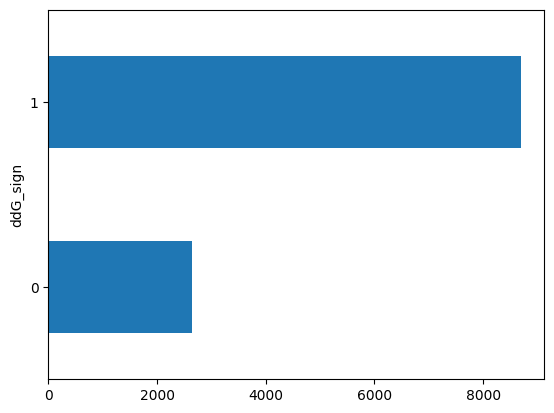

In [9]:
import matplotlib.pyplot as plt
df['ddG_sign'].value_counts().sort_values().plot(kind = 'barh')

****Классы несбалансированны, это будет необходимо учитывать при построении модели.****

In [10]:
deltas = df.apply(lambda r: aa_delta(r["wild"], r["mut"]), axis=1, result_type="expand")
deltas.columns = ["d_hydro", "d_vol", "d_charge"]
df = pd.concat([df, deltas], axis=1)
df["blosum62"] = df.apply(lambda r: blosum_score(r["wild"], r["mut"]), axis=1)
df["rel_pos"] = df["pos"]
df["mass_diff"] = df.apply(lambda r: mass_delta(r["wild"], r["mut"]), axis=1)
df["same_group"] = df.apply(lambda r: same_group(r["wild"], r["mut"]), axis=1)

### Локализация мутации и её влияние

Каждая мутация имеет определённую пространственную локализацию в структуре белка (`location_list`).  
Мы вводим числовое отображение этой категории (`loc_score`) с приоритетом: **SUR < RIM < SUP < INT < COR**, где:

- **SUR (surface)** — поверхностная область  
- **COR (core)** — центр белка  
- остальные — промежуточные слои

Также учитывается средняя тенденция для каждой зоны (`loc_ddg_avg`) — насколько часто мутации в этой зоне приводят к изменению свободной энергии.

#### Инженерия новых признаков:

- `loc_score_dvol = loc_score × d_vol`: связывает глубину мутации с изменением объёма аминокислот
- `loc_score_blosum = loc_score × blosum62`: связывает глубину мутации с "заменимостью" аминокислот по BLOSUM62

Эти признаки помогают захватить интеракцию между структурной позицией и типом замены.

In [11]:
location_map = {'COR': 4, 'INT': 3, 'SUP': 2, 'RIM': 1, 'SUR': 0}
df["loc_score"] = df["location_list"].map(location_map)

loc_ddg_mean = df.groupby("location_list")["ddG_sign"].mean()
df["loc_ddg_avg"] = df["location_list"].map(loc_ddg_mean)

df["loc_score_dvol"] = df["loc_score"] * df["d_vol"]
df["loc_score_blosum"] = df["loc_score"] * df["blosum62"]

In [12]:
df

,#Pdb,ddG_sign,wild,chain_id,pos,mut,location_list,Method,d_hydro,d_vol,d_charge,blosum62,rel_pos,mass_diff,same_group,loc_score,loc_ddg_avg,loc_score_dvol,loc_score_blosum
0,1CSE_E_I,1,L,I,38,G,COR,IASP,-4.2,-106.6,0.0,-4.0,38,-56.10,0,4,0.831032,-426.4,-16.0
1,1CSE_E_I,1,L,I,38,S,COR,IASP,-4.6,-77.7,0.0,-2.0,38,-26.08,0,4,0.831032,-310.8,-8.0
2,1CSE_E_I,1,L,I,38,P,COR,IASP,-5.4,-54.0,0.0,-3.0,38,-16.04,0,4,0.831032,-216.0,-12.0
3,1CSE_E_I,1,L,I,38,I,COR,IASP,0.7,0.0,0.0,2.0,38,0.00,1,4,0.831032,0.0,8.0
4,1CSE_E_I,1,L,I,38,D,COR,IASP,-7.3,-55.6,-1.0,-4.0,38,1.93,0,4,0.831032,-222.4,-16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7081,3QIB_ABP_CD,1,T,P,11,A,COR,SPR,2.5,-27.5,0.0,0.0,11,-30.03,0,4,0.831032,-110.0,0.0
7082,3QIB_ABP_CD,1,T,P,11,S,COR,SPR,-0.1,-27.1,0.0,1.0,11,-14.03,1,4,0.831032,-108.4,4.0
7083,3QIB_ABP_CD,1,T,P,11,N,COR,SPR,-2.8,-2.0,0.0,0.0,11,13.00,1,4,0.831032,-8.0,0.0
7084,3QIB_ABP_CD,1,Y,P,6,F,COR,SPR,4.1,-3.2,0.0,3.0,6,-16.00,1,4,0.831032,-12.8,12.0


### Деление признаков на категориальные и числовые

Для подготовки данных мы разделили признаки на:

#### Категориальные (`CATEGORICAL`):
- `wild`: аминокислота в позиции до мутации
- `mut`: аминокислота после мутации
- `Method`: метод измерения

Эти признаки нужно one-hot-кодировать перед подачей в модель (кроме catboost модели, где one-hot делается автоматически)

#### Числовые (`NUMERICAL`):
- `d_hydro`, `d_vol`, `d_charge`: изменения гидрофобности, объёма и заряда при мутации
- `blosum62`: "заменимость" аминокислот по матрице BLOSUM62
- `rel_pos`: позиция мутации вдоль белковой последовательности (нормализованная)
- `mass_diff`: разница масс между `mut` и `wild`
- `same_group`: флаг — осталась ли аминокислота в той же химической группе
- `loc_score`: числовая оценка глубины мутации в белке
- `loc_ddg_avg`: средний эффект мутаций в данной области
- `loc_score_dvol`: взаимодействие глубины и изменения объёма
- `loc_score_blosum`: взаимодействие глубины и BLOSUM-заменимости

Это деление важно для правильной предобработки и подачи признаков в модели ML.

In [13]:
CATEGORICAL = ["wild", "mut", 'Method']

NUMERICAL = [
    "d_hydro", "d_vol", "d_charge", "blosum62", "rel_pos", 
    "mass_diff", "same_group", "loc_score", "loc_ddg_avg", 
    "loc_score_dvol", "loc_score_blosum"
]

In [14]:
X = df[CATEGORICAL + NUMERICAL]
y = df['ddG_sign']

In [15]:
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", StandardScaler(), NUMERICAL)
])

### ML-пайплайны

Создаём два отдельных пайплайна — для логистической регрессии и K-ближайших соседей

In [16]:
# пайплайн для лог. регрессии
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

# пайплайн для knn
knn_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", KNeighborsClassifier())
])

### Кросс-валидация и метрики

Применяется **Stratified K-Fold кросс-валидация** с 5 фолдами. Это помогает честно оценить модель: каждый объект хотя бы раз попадает в валидацию, а стратификация сохраняет пропорции классов в каждом фолде.

#### Метрики

Из-за перекоса классов стандартная точность (`accuracy`) может быть неинформативной. Вместо неё рассчитываются:

- `Balanced Accuracy` — корректно отражает качество при несбалансированных классах
- `MCC` — универсальная метрика бинарной классификации, устойчива к дисбалансу
- `F1-score` — среднее между точностью и полнотой, полезно, когда один класс более важен
- `ROC AUC` — отражает качество ранжирования предсказаний

Такой набор метрик даёт более объективную и устойчивую картину производительности модели.


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    'balanced_accuracy': [],
    'mcc': [],
    'f1': [],
    'roc_auc': []
}

In [18]:
#обуччение для logreg

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    y_prob = pipeline.predict_proba(X_val)[:, 1]

    metrics['balanced_accuracy'].append(balanced_accuracy_score(y_val, y_pred))
    metrics['mcc'].append(matthews_corrcoef(y_val, y_pred))
    metrics['f1'].append(f1_score(y_val, y_pred))
    metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))

for metric_name, values in metrics.items():
    print(f"{metric_name}: {np.mean(values):.4f} ± {np.std(values):.4f}")

balanced_accuracy: 0.5785 ± 0.0049
mcc: 0.2454 ± 0.0152
f1: 0.8701 ± 0.0024
roc_auc: 0.7316 ± 0.0074


### Результаты логистической регрессии

```
balanced_accuracy: 0.5785 ± 0.0049
mcc: 0.2454 ± 0.0152
f1: 0.8701 ± 0.0024
roc_auc: 0.7316 ± 0.0074
```

Модель показала низкие значения `balanced_accuracy` и `MCC`, что указывает на слабую способность отличать классы при дисбалансе. Несмотря на высокий `F1-score`, это скорее отражение того, что модель «предпочитает» один класс. Значение `ROC AUC` находится на среднем уровне, но в целом модель не справилась с задачей: предсказания слабо различают классы, и сбалансированность страдает.

In [19]:
# кросс-валидация + грид серч для K ближаййших соседей

param_grid = {
    "clf__n_neighbors": [4, 8, 10, 20],
    "clf__metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)
best_model = grid.best_estimator_

print(f"\nBest params: {grid.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 4}


In [22]:
for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1]

    metrics['balanced_accuracy'].append(balanced_accuracy_score(y_val, y_pred))
    metrics['mcc'].append(matthews_corrcoef(y_val, y_pred))
    metrics['f1'].append(f1_score(y_val, y_pred))
    metrics['roc_auc'].append(roc_auc_score(y_val, y_prob))

print("\nCross-validated scores:")
for metric_name, values in metrics.items():
    print(f"{metric_name}: {np.mean(values):.4f} ± {np.std(values):.4f}")


Cross-validated scores:
balanced_accuracy: 0.6987 ± 0.0710
mcc: 0.4071 ± 0.0980
f1: 0.8678 ± 0.0080
roc_auc: 0.7893 ± 0.0362


### Итоги модели KNN: не провал, но и не победа

Даже несмотря на настройку гиперпараметров через `GridSearchCV`, итоговые метрики нельзя назвать высокими:

- **Balanced Accuracy** в среднем ~0.69 — по сути, модель чуть лучше угадывает класс, чем случайно.
- **MCC** около 0.40 — это слабая корреляция между предсказаниями и истиной.
- **F1-score** остаётся высоким (~0.87), но это может быть связано с перекосом в сторону одного класса.
- **ROC AUC** ~0.78 — адекватно, но не что-то выдающееся.

**Вывод**: модель KNN отрабатывает лучше логистической регрессии, но всё ещё не справляется достаточно хорошо, чтобы использовать её в серьёзной задаче. Особенно при дисбалансе классов. Возможно, стоит двигаться дальше — к более сложным моделям, таким как градиентный бустинг или нейросети.

## CatBoost

In [23]:
X_cat = df[CATEGORICAL]
X_num = df[NUMERICAL]
y = df["ddG_sign"]

In [25]:
cb_params = dict(
    iterations=5000,
    depth=9,
    learning_rate=0.02,
    loss_function="Logloss",
    eval_metric="Logloss",
    l2_leaf_reg=5.0,
    random_seed=42,
    verbose=200,
    early_stopping_rounds=300,
    od_type="Iter",               
    auto_class_weights="Balanced"
)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bacc, mcc = [], []
all_importances = []
f1 = []
roc_auc = []

In [26]:
for tr_idx, val_idx in skf.split(df, y):
    train_pool = Pool(
        data=pd.concat([X_cat.iloc[tr_idx], X_num.iloc[tr_idx]], axis=1),
        label=y.iloc[tr_idx],
        cat_features=list(range(len(CATEGORICAL))),
    )
    val_pool = Pool(
        data=pd.concat([X_cat.iloc[val_idx], X_num.iloc[val_idx]], axis=1),
        label=y.iloc[val_idx],
        cat_features=list(range(len(CATEGORICAL))),
    )
    model = CatBoostClassifier(**cb_params)
    model.fit(train_pool, eval_set=val_pool)
    feature_names = list(X_cat.columns) + list(X_num.columns)
    importances = model.get_feature_importance(train_pool)
    fold_importances = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    all_importances.append(fold_importances)

    preds = (model.predict(val_pool).ravel()).astype(int)

    bacc.append(balanced_accuracy_score(y.iloc[val_idx], preds))
    mcc.append(matthews_corrcoef(y.iloc[val_idx], preds))
    f1.append(f1_score(y.iloc[val_idx], preds))
    roc_auc.append(roc_auc_score(y.iloc[val_idx], preds))

print(f"Balanced ACC  (5-fold): {np.mean(bacc):.3f} ± {np.std(bacc):.3f}")
print(f"MCC           (5-fold): {np.mean(mcc):.3f} ± {np.std(mcc):.3f}")
print(f"F1-score      (5-fold): {np.mean(f1):.3f} ± {np.std(f1):.3f}")
print(f"ROC AUC       (5-fold): {np.mean(roc_auc):.3f} ± {np.std(roc_auc):.3f}")

0:	learn: 0.6884278	test: 0.6886443	best: 0.6886443 (0)	total: 70.9ms	remaining: 5m 54s
200:	learn: 0.4502642	test: 0.4911850	best: 0.4911850 (200)	total: 3.29s	remaining: 1m 18s
400:	learn: 0.3986232	test: 0.4779954	best: 0.4779954 (400)	total: 6.46s	remaining: 1m 14s
600:	learn: 0.3503123	test: 0.4683194	best: 0.4683194 (600)	total: 10.2s	remaining: 1m 14s
800:	learn: 0.3129739	test: 0.4611880	best: 0.4611880 (800)	total: 13.6s	remaining: 1m 11s
1000:	learn: 0.2834661	test: 0.4585942	best: 0.4584011 (988)	total: 17.1s	remaining: 1m 8s
1200:	learn: 0.2609141	test: 0.4577064	best: 0.4576863 (1185)	total: 20.6s	remaining: 1m 5s
1400:	learn: 0.2419584	test: 0.4579051	best: 0.4572492 (1245)	total: 24.2s	remaining: 1m 2s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.4572491522
bestIteration = 1245

Shrink model to first 1246 iterations.
0:	learn: 0.6877540	test: 0.6885186	best: 0.6885186 (0)	total: 19.1ms	remaining: 1m 35s
200:	learn: 0.4471681	test: 0.5072495	best: 

### Итоги модели CatBoost: достаточно сильный результат, но есть пространство для улучшений

После обучения модели CatBoost, получены следующие результаты:

- **Balanced Accuracy** ~0.77 — модель достаточно хорошо справляется с балансом классов, но есть пространство для улучшений.
- **MCC** около 0.51 — слабая, но позитивная корреляция между предсказаниями и истиной, что указывает на прогресс по сравнению с базовыми моделями.
- **F1-score** ~0.87 — высокий, но это также может указывать на перекос в сторону одного из классов, тем не менее BACC повысилась, поэтому можно считать, что f1 в этом контексте стала более информативной
- **ROC AUC** ~0.77 — достойный результат, хотя и не на максимальном уровне, что оставляет поле для дальнейшей оптимизации.

**Вывод**: Модель CatBoost продемонстрировала хорошие результаты, особенно учитывая использование авто-классовых весов и настройку гиперпараметров. Однако, есть возможность улучшить её стабильность и точность. Можно попробовать дополнительные оптимизации гиперпараметров, использовать более сложные архитектуры или дополнительно работать с балансировкой классов для достижения лучших показателей.

In [29]:
importances_df = pd.concat(all_importances)
mean_importance = (
    importances_df.groupby("feature")
    .importance.mean()
    .sort_values(ascending=False)
)

mean_importance

feature
Method              20.067685
wild                15.836242
rel_pos             14.715765
mut                 11.671464
loc_score_dvol       6.621704
loc_ddg_avg          6.028421
d_hydro              5.074557
loc_score            4.027443
mass_diff            3.315307
d_vol                3.154970
loc_score_blosum     2.861992
blosum62             2.578438
d_charge             2.023173
same_group           2.022838
Name: importance, dtype: float64

### Важность признаков в модели

Наиболее значимыми признаками для модели являются `Method`, `wild`, `rel_pos`, и `mut`. Эти признаки, вероятно, оказывают наибольшее влияние на предсказания модели, в то время как такие признаки, как `same_group`, `d_charge`, и `blosum62`, имеют меньший вклад в общее поведение модели.
